<a href="https://colab.research.google.com/github/anirbansen2709/AI-ML_Assignments/blob/main/Team_28_DP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Reinforcement Learning - Lab Assignment 1
## PART #2 - DP: Autonomous Drone Rescue Using Dynamic Programming

This notebook solves **Part #2 - DP** only. It implements a finite MDP for the drone rescue scenario and computes an optimal policy using **Value Iteration**.

**Problem Statement**

Design and implement a reinforcement learning agent using dynamic programming - Value Iteration or
Policy Iteration to compute an optimal policy for an autonomous rescue drone operating in a disaster zone.
The drone must learn how to rescue stranded civilians while managing battery power, avoiding dangerous
zones, and reaching charging stations when necessary. The problem must be modelled as a finite Markov
Decision Process (MDP).

### Questions answered in this notebook
1. How can the Drone Rescue problem be modelled as a finite Markov Decision Process?
2. How should the custom environment handle battery, rescue targets, charging, blocked cells, danger zones and wind?
3. How can Dynamic Programming compute the optimal value function and optimal policy?
4. How can the policy, rescue sequence, charging behavior and value function be visualized?
5. Why does Dynamic Programming become difficult as the environment becomes larger?

In [ ]:
# ================================================================
# Assignment configuration cell
# ================================================================
# The grid size, maximum battery, wind probability and object counts are derived from GROUP_ID.
GROUP_ID = 28

# Dynamic Programming hyperparameters.
# GAMMA discounts future rescue rewards so that shorter, safer rescue plans are preferred.
GAMMA = 0.95

# THETA is the stopping threshold required in the assignment.
THETA = 0.001

# A fixed random seed is used for reproducible layout generation and stochastic simulations.
RANDOM_SEED = GROUP_ID

In [ ]:
# ================================================================
# Imports and execution metadata
# ================================================================
# Standard library imports are used for time measurement, machine metadata and deterministic randomness.
import os
import socket
import time
import uuid
import platform
from dataclasses import dataclass
from datetime import datetime
from collections import deque, defaultdict

# Numerical and plotting libraries used for DP arrays, tabular summaries and visualizations.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# This cell prints timestamp and VM identifiers at the top of the notebook, as required.
execution_timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
host_name = socket.gethostname()
platform_details = platform.platform()

# /etc/machine-id is commonly present in Linux virtual labs; fallback keeps the notebook portable.
try:
    with open('/etc/machine-id', 'r', encoding='utf-8') as f:
        vm_machine_id = f.read().strip()
except Exception:
    vm_machine_id = str(uuid.getnode())

print('Execution timestamp:', execution_timestamp)
print('VM / Host name:', host_name)
print('VM machine id:', vm_machine_id)
print('Platform:', platform_details)
print('Configured GROUP_ID:', GROUP_ID)

Execution timestamp: 2026-06-08 01:46:04
VM / Host name: 2025aa05327
VM machine id: ec2dea449c6695d5764ba96a11047ce4
Platform: Linux-5.14.0-503.14.1.el9_5.x86_64-x86_64-with-glibc2.34
Configured GROUP_ID: 28


### Assignment Screenshot with Timestamp in Virtual Lab

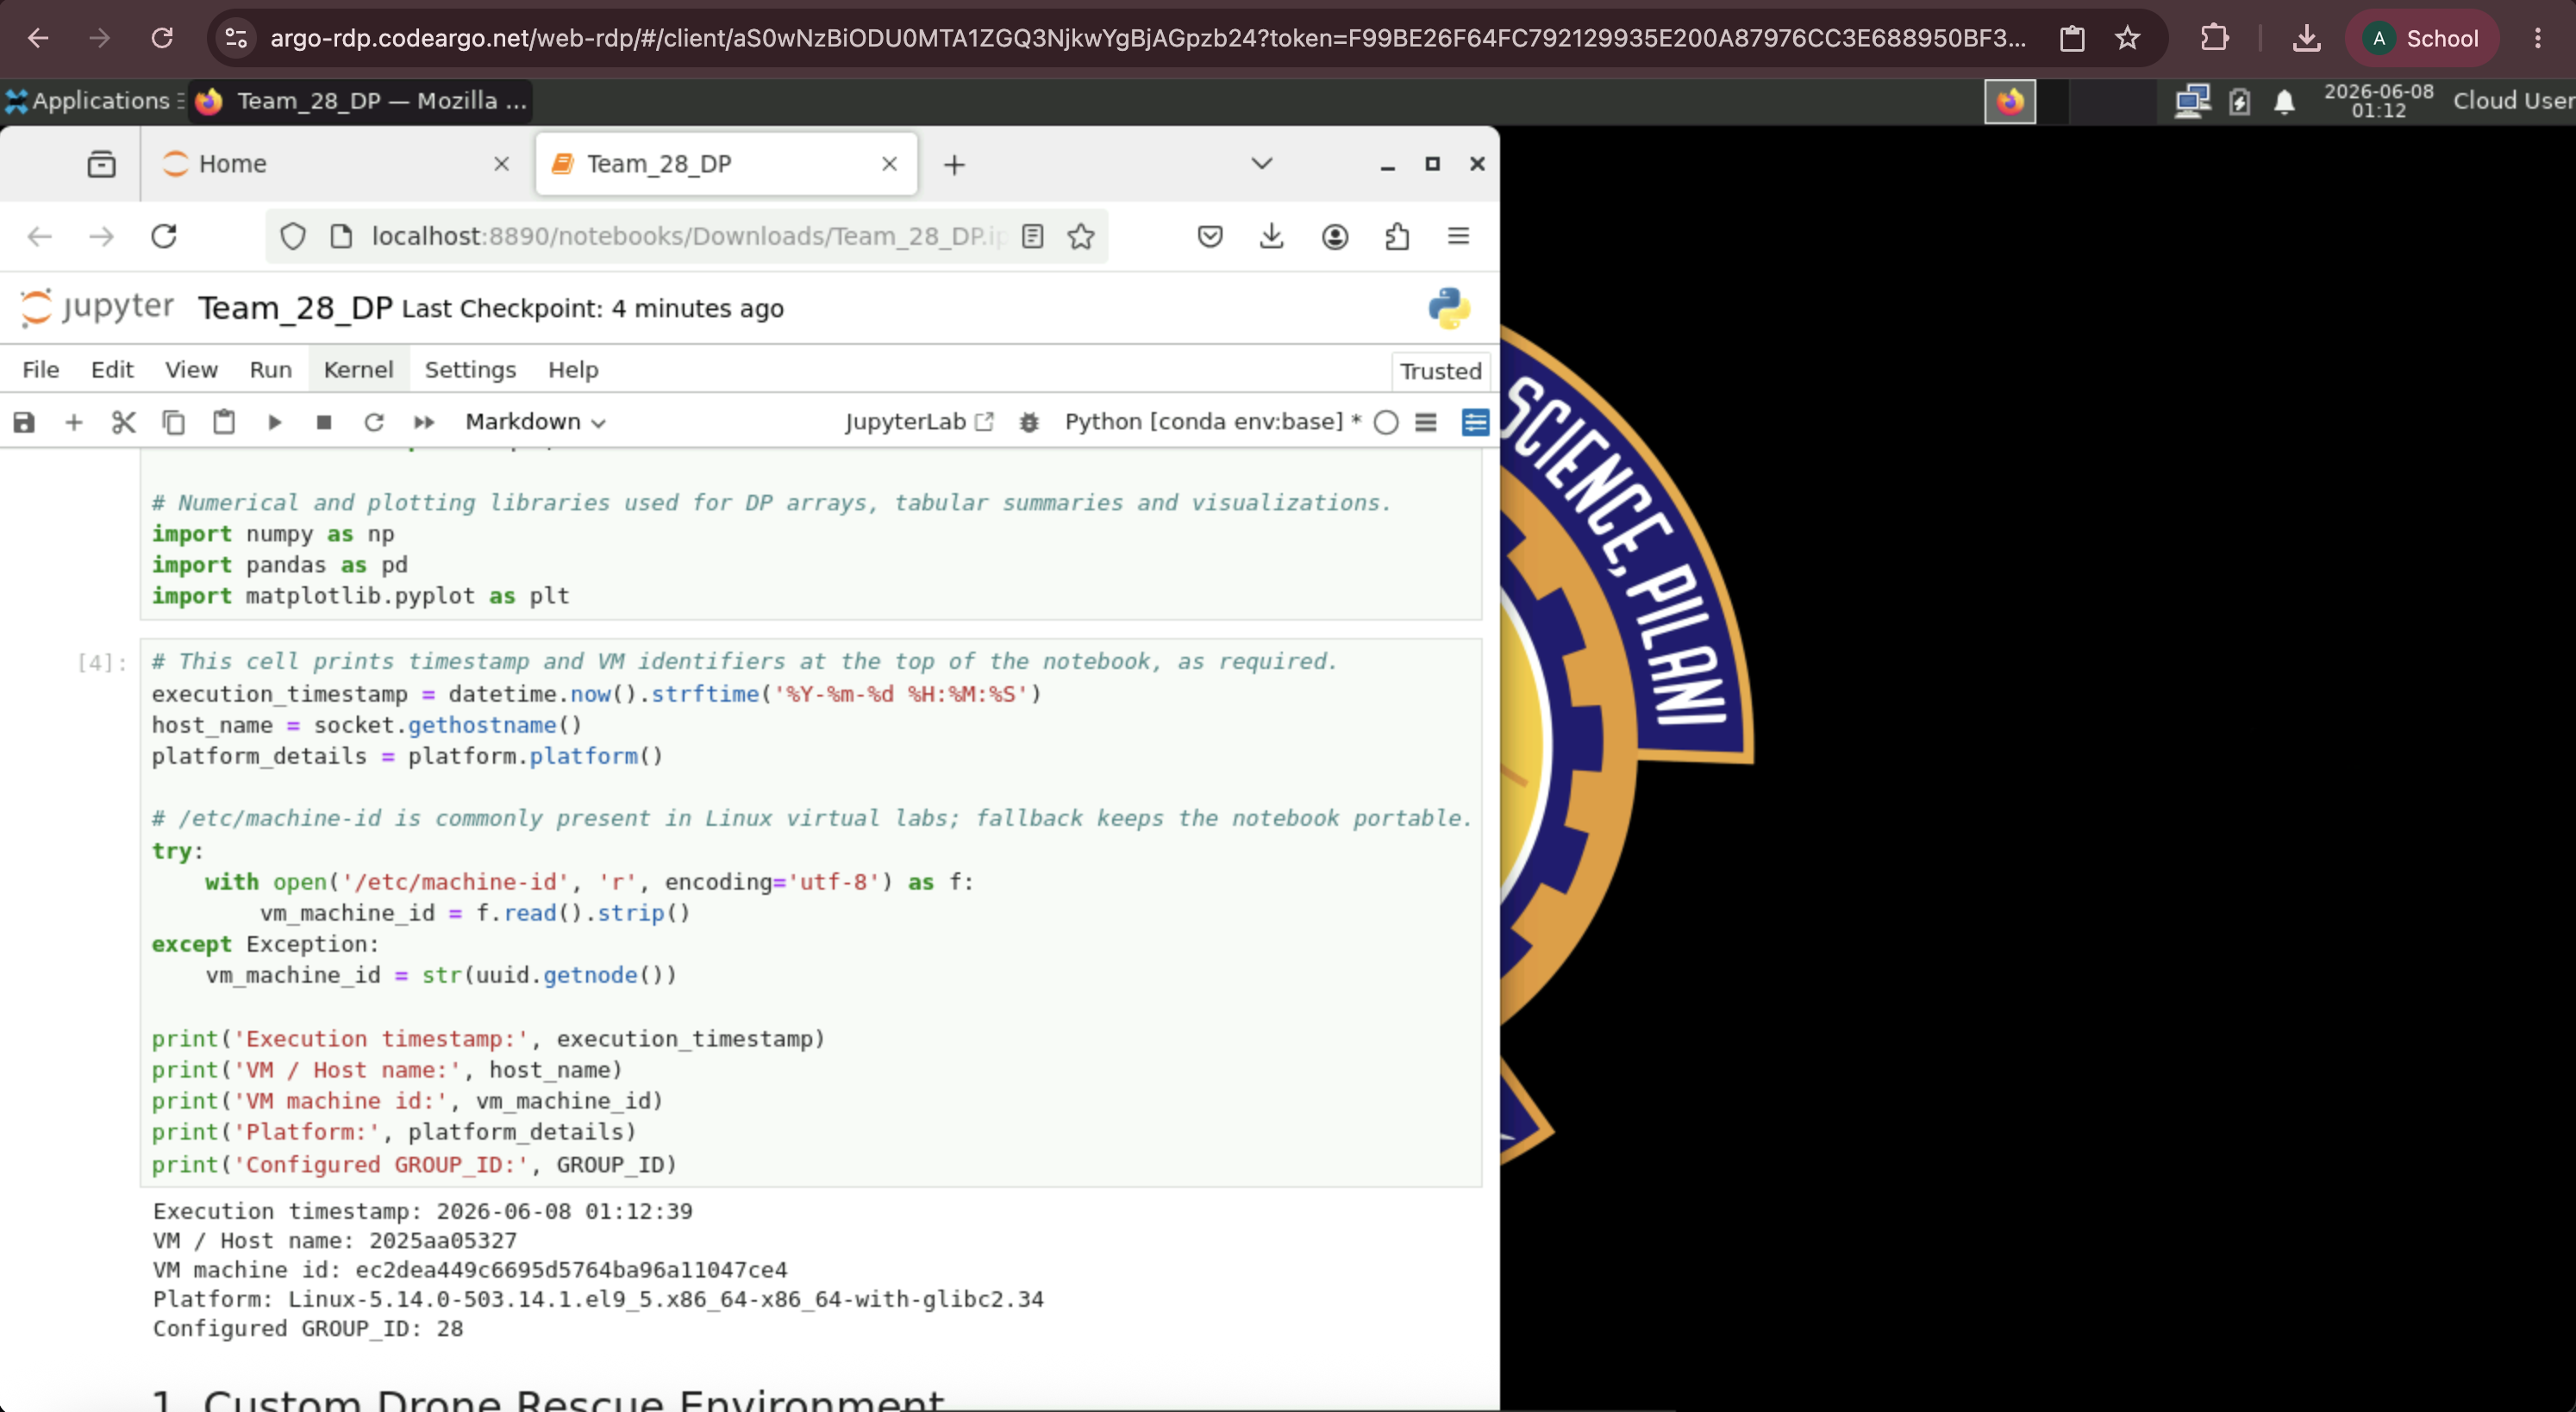

## 1. Custom Drone Rescue Environment

In this section, we implement the autonomous drone rescue simulation as a finite Markov Decision Process (MDP).

The Python code below defines the DroneRescueEnv class, which programmatically generates the environment. Rather than hard-coding a static grid, this class dynamically constructs the state space, action space, transition probabilities, and reward structures based on the specific parameters assigned to **Group 28.**

The environment encapsulates all logic for:

* Tracking the drone's spatial position and battery degradation.

* Resolving stochastic movement (wind disruptions).

* Applying the assignment's exact reward and penalty structure.

* Providing exact transition probabilities required for Dynamic Programming updates.

*The specific grid layout and formal MDP mathematical formulation generated by this configuration are detailed immediately following the code output.*

In [ ]:
# ================================================================
# Data classes and environment definition
# ================================================================
@dataclass(frozen=True)
class DroneConfig:
    """Stores all group-dependent configuration values for the drone rescue MDP."""
    group_id: int
    grid_size: int
    max_battery: int
    step_limit: int
    wind_probability: float
    rescue_count: int
    charging_count: int
    danger_count: int
    blocked_count: int
    wind_count: int

In [ ]:
class DroneRescueEnv:
    """Custom finite MDP environment for the Autonomous Drone Rescue assignment.

    The class provides reset(), step(action) and render() methods for simulation,
    and transition_model(state, action) for exact Dynamic Programming updates.
    """
    # Action mapping keeps code readable and avoids repeated string comparisons.
    ACTIONS = ['UP', 'DOWN', 'LEFT', 'RIGHT', 'HOVER']
    MOVE_DELTAS = {
        'UP': (-1, 0),
        'DOWN': (1, 0),
        'LEFT': (0, -1),
        'RIGHT': (0, 1),
        'HOVER': (0, 0)
    }
    ARROWS = {
        'UP': '↑',
        'DOWN': '↓',
        'LEFT': '←',
        'RIGHT': '→',
        'HOVER': '•'
    }

    def __init__(self, group_id: int, seed: int | None = None):
        """Create a deterministic group-specific rescue environment.
        Args:
            group_id: Assignment group number used to derive grid size and parameters.
            seed: Optional seed for reproducible layout generation and stochastic steps.
        """
        self.group_id = int(group_id)
        self.seed = int(group_id if seed is None else seed)
        self.rng = np.random.default_rng(self.seed)
        self.config = self._build_config()
        self.start_pos = (0, 0)
        self.grid, self.rescue_targets, self.charging_stations, self.danger_zones, self.blocked_cells, self.wind_zones = self._generate_layout()
        self.reset()

    def _build_config(self) -> DroneConfig:
        """Derive all environment parameters from the group ID rules in the assignment."""
        last_digit = self.group_id % 10
        grid_size = 5 if last_digit <= 4 else 6
        max_battery = 10 if last_digit % 2 == 0 else 15
        step_limit = 50 if grid_size == 5 else 75
        wind_probability = 0.20 if last_digit <= 4 else 0.30
        # The assignment specifies counts for rescue, charging, danger and blocked cells.
        if grid_size == 5:
            rescue_count, charging_count, danger_count, blocked_count = 2, 1, 3, 2
            wind_count = 2  # Wind count is not fixed in the PDF; this group-dependent design uses 2 for 5x5.
        else:
            rescue_count, charging_count, danger_count, blocked_count = 3, 2, 4, 3
            wind_count = 3  # Wind count is not fixed in the PDF; this design scales wind zones for 6x6.
        return DroneConfig(
            group_id=self.group_id,
            grid_size=grid_size,
            max_battery=max_battery,
            step_limit=step_limit,
            wind_probability=wind_probability,
            rescue_count=rescue_count,
            charging_count=charging_count,
            danger_count=danger_count,
            blocked_count=blocked_count,
            wind_count=wind_count
        )

    def _generate_layout(self):
        """Generate a reproducible grid layout whose special cell placement depends on GROUP_ID.
        The start cell is fixed at the top-left corner as required. All other special
        locations are selected by a group-seeded permutation, making the notebook
        reproducible but still different across groups.
        """
        n = self.config.grid_size
        grid = np.full((n, n), 'F', dtype='<U1')
        grid[self.start_pos] = 'S'
        # Candidate cells exclude the fixed start position.
        candidate_cells = [(r, c) for r in range(n) for c in range(n) if (r, c) != self.start_pos]
        candidate_cells = np.array(candidate_cells, dtype=object)
        self.rng.shuffle(candidate_cells)
        candidate_cells = [tuple(cell) for cell in candidate_cells]
        # Slice the shuffled list into each special category.
        idx = 0
        rescue_targets = tuple(candidate_cells[idx:idx + self.config.rescue_count]); idx += self.config.rescue_count
        charging_stations = tuple(candidate_cells[idx:idx + self.config.charging_count]); idx += self.config.charging_count
        danger_zones = tuple(candidate_cells[idx:idx + self.config.danger_count]); idx += self.config.danger_count
        blocked_cells = tuple(candidate_cells[idx:idx + self.config.blocked_count]); idx += self.config.blocked_count
        wind_zones = tuple(candidate_cells[idx:idx + self.config.wind_count]); idx += self.config.wind_count
        # Mark grid symbols after allocation.
        for cell in rescue_targets:
            grid[cell] = 'R'
        for cell in charging_stations:
            grid[cell] = 'C'
        for cell in danger_zones:
            grid[cell] = 'D'
        for cell in blocked_cells:
            grid[cell] = 'X'
        for cell in wind_zones:
            grid[cell] = 'W'
        return grid, rescue_targets, charging_stations, danger_zones, blocked_cells, wind_zones

    def reset(self):
        """Reset the simulation to the initial state and return that state."""
        self.position = self.start_pos
        self.battery = self.config.max_battery
        self.rescue_mask = (1 << len(self.rescue_targets)) - 1  # 1 means target still pending.
        self.steps = 0
        self.done = False
        self.total_reward = 0.0
        return self._current_state()

    def _current_state(self):
        """Return the current MDP state tuple used by the DP algorithm."""
        r, c = self.position
        return (r, c, self.battery, self.rescue_mask)

    def is_terminal_state(self, state):
        """Check terminal states used by DP: no battery or all targets rescued."""
        _, _, battery, rescue_mask = state
        return battery <= 0 or rescue_mask == 0

    def valid_actions(self, state):
        """Return actions available from a state.
        All five actions are returned because the environment defines outcomes for
        boundaries and blocked cells: the drone remains in place and still consumes
        battery. This keeps the MDP complete while respecting blocked-cell rules.
        """
        if self.is_terminal_state(state):
            return []
        return list(self.ACTIONS)

    def _inside_grid(self, row, col):
        """Check whether a candidate position is within the grid boundaries."""
        return 0 <= row < self.config.grid_size and 0 <= col < self.config.grid_size

    def _apply_movement(self, position, actual_action):
        """Apply movement while preventing the drone from entering blocked/outside cells."""
        r, c = position
        dr, dc = self.MOVE_DELTAS[actual_action]
        nr, nc = r + dr, c + dc
        # Invalid movement into wall or debris keeps the drone in the same cell.
        if not self._inside_grid(nr, nc) or (nr, nc) in self.blocked_cells:
            return position
        return (nr, nc)

    def _reward_and_next_state(self, state, actual_action):
        """Compute next state, reward and done flag for a realized action direction."""
        r, c, battery, rescue_mask = state
        current_pos = (r, c)
        next_pos = self._apply_movement(current_pos, actual_action)
        # Every action has a regular operating cost.
        reward = -1.0
        # Hovering on a charging station receives a net battery gain as specified.
        if actual_action == 'HOVER' and current_pos in self.charging_stations:
            next_battery = min(self.config.max_battery, battery + 2)
        else:
            next_battery = battery - 1
        # Entering or staying on a charging station refills the battery and adds charging reward.
        if next_pos in self.charging_stations:
            next_battery = self.config.max_battery
            reward += 5.0
        # Danger zones are allowed but penalized heavily.
        if next_pos in self.danger_zones:
            reward += -10.0
        # Rescue reward is given only the first time a pending target is reached.
        new_mask = rescue_mask
        for target_index, target_pos in enumerate(self.rescue_targets):
            # Create a bitmask for the current target (e.g., target 0 = 001, target 1 = 010)
            target_bit = 1 << target_index
            # Check if drone position matches target position AND if the bit is '1' (pending)
            if next_pos == target_pos and (rescue_mask & target_bit):
                reward += 20.0
                # Bitwise AND with NOT bit (~target_bit) flips the status bit to '0' (rescued)
                new_mask = rescue_mask & (~target_bit)
                # Break after one rescue to ensure only one target is processed per move
                break
        # Battery exhaustion terminates the episode immediately and adds penalty.
        done = False
        # If battery reaches 0 or below, it's a terminal state with a -20 penalty
        if next_battery <= 0:
            next_battery = 0
            reward += -20.0
            done = True
        # If all targets are rescued (mask becomes 0), it's a terminal state
        if new_mask == 0:
            done = True
        # Package the result as a state tuple (row, col, battery, new_mask)
        nr, nc = next_pos
        next_state = (nr, nc, next_battery, new_mask)
        return next_state, reward, done

    def transition_model(self, state, action):
        """Return exact transition probabilities for DP updates.
        Wind stochasticity is applied only when the drone starts on a wind cell and
        attempts a movement action. Probabilities are aggregated when multiple
        wind outcomes lead to the same next state.
        Input - (r, c, b, m), action
        Output - This lists every possible outcome of that action (accounting for wind) and the likelihood of each.
        """
        # If the current state is terminal, no actions are possible, return empty list
        if self.is_terminal_state(state):
            return []
        # Unpack the state tuple to get the current row and column
        r, c, _, _ = state
        current_pos = (r, c)
        # Define the set of directional movement actions subject to wind
        movement_actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
        # Dictionary to accumulate the probability of each "realized" action
        # (e.g., if you choose UP but wind pushes you DOWN)
        action_distribution = defaultdict(float)
        # Check if the drone is in a wind zone AND the action is a movement action
        if current_pos in self.wind_zones and action in movement_actions:
            # The drone follows the intended action with (1 - p_wind) probability
            p_wind = self.config.wind_probability
            action_distribution[action] += 1.0 - p_wind
            # Or the wind overrides the movement with a random direction (p_wind / 4.0)
            for random_action in movement_actions:
                action_distribution[random_action] += p_wind / 4.0
        else:
            # If no wind or not a movement action (e.g., HOVER), the action is deterministic
            action_distribution[action] = 1.0
        # Dictionary to aggregate probabilities that lead to the same (next_state, reward, done)
        transition_distribution = defaultdict(lambda: [0.0, 0.0, False])
        # Iterate over all possible realized actions and their probabilities
        for actual_action, prob in action_distribution.items():
            # Calculate what happens to the environment for each realized action
            next_state, reward, done = self._reward_and_next_state(state, actual_action)
            # Create a unique key based on the outcome
            key = (next_state, reward, done)
            # Add the probability to the total for this specific outcome
            transition_distribution[key][0] += prob
        # Format the final list of (probability, next_state, reward, done) tuples
        return [(prob, next_state, reward, done) for (next_state, reward, done), (prob, _, _) in transition_distribution.items()]

    def step(self, action):
        """This function executes a single move, updates the environment's internal state, and returns the results."""
        # Checks if the episode is already finished
        if self.done:
            return self._current_state(), 0.0, True, {'message': 'Episode already finished'}
        # Validates that the requested action is permitted. If not, it raises a ValueError.
        if action not in self.valid_actions(self._current_state()):
            raise ValueError(f'Invalid action {action}. Valid actions are {self.valid_actions(self._current_state())}.')
        # Calls the transition engine to get all possible outcomes of the action
        transitions = self.transition_model(self._current_state(), action)
        # Extracts the probability values for each possible outcome.
        probabilities = [item[0] for item in transitions]
        # Uses the random number generator to sample one specific outcome based on the calculated probabilities.
        selected_index = self.rng.choice(len(transitions), p=probabilities)
        # Unpacks the chosen transition details.
        _, next_state, reward, terminal_from_state = transitions[selected_index]
        # Unpacks the new state tuple.
        r, c, battery, rescue_mask = next_state
        # Updates the environment's internal variables to reflect the new state.
        self.position = (r, c)
        self.battery = battery
        self.rescue_mask = rescue_mask
        # Increments the step counter. Adds the step's reward to the running total.
        self.steps += 1
        self.total_reward += reward
        # Sets the termination flag if the transition ended the episode OR if the max step limit (50 or 75) has been reached.
        self.done = terminal_from_state or self.steps >= self.config.step_limit
        # Constructs a dictionary containing metadata for the step.
        info = {
            'steps': self.steps,
            'battery': self.battery,
            'rescue_mask': self.rescue_mask,
            'total_reward': self.total_reward
        }
        # Returns the step's outcome to the caller.
        return next_state, reward, self.done, info

    def render(self, state=None):
        """Print a human-readable grid showing the drone location and current symbols."""
        # If no specific state is provided, it defaults to the environment's current internal state.
        if state is None:
            state = self._current_state()
        # Unpacks the state tuple.
        r, c, battery, rescue_mask = state
        # Creates a copy of the base grid so it doesn't modify the permanent environment layout.
        display_grid = self.grid.copy()
        # Loops through all target locations.
        for target_index, target_pos in enumerate(self.rescue_targets):
          # If a target's bit in the mask is 0 (rescued), it updates the symbol on the display grid from 'R' to 'F' (Free).
            if not (rescue_mask & (1 << target_index)):
                display_grid[target_pos] = 'F'
        # Places the active drone symbol ('A') at the drone's current position.
        display_grid[r, c] = 'A'
        print('Battery:', battery, '| Pending rescue mask:', rescue_mask)
        print(pd.DataFrame(display_grid).to_string(index=False, header=False))

    def describe(self):
        """Return a compact table of the group-specific environment configuration."""
        rows = [
            ('Group ID', self.config.group_id),
            ('Grid size', f'{self.config.grid_size} x {self.config.grid_size}'),
            ('Maximum battery', self.config.max_battery),
            ('Step limit', self.config.step_limit),
            ('Wind probability', self.config.wind_probability),
            ('Start position', self.start_pos),
            ('Rescue targets', self.rescue_targets),
            ('Charging stations', self.charging_stations),
            ('Danger zones', self.danger_zones),
            ('Blocked cells', self.blocked_cells),
            ('Wind zones', self.wind_zones),
        ]
        return pd.DataFrame(rows, columns=['Parameter', 'Value'])

In [ ]:
# ================================================================
# Create and inspect the custom environment
# ================================================================
# The environment is generated once from GROUP_ID and RANDOM_SEED.
env = DroneRescueEnv(group_id=GROUP_ID, seed=RANDOM_SEED)
print("Environment configuration")
display(env.describe())
print("\nRender the initial grid. A = active drone, S = start, R = rescue, C = charging, D = danger, W = wind, X = blocked, F = free/safe.\n")
env.render()

Environment configuration


,Parameter,Value
0,Group ID,28
1,Grid size,6 x 6
2,Maximum battery,10
3,Step limit,75
4,Wind probability,0.3
5,Start position,"(0, 0)"
6,Rescue targets,"((5, 2), (2, 1), (3, 2))"
7,Charging stations,"((1, 3), (2, 2))"
8,Danger zones,"((1, 4), (2, 3), (0, 5), (2, 5))"
9,Blocked cells,"((1, 5), (1, 2), (4, 3))"



Render the initial grid. A = active drone, S = start, R = rescue, C = charging, D = danger, W = wind, X = blocked, F = free/safe.

Battery: 10 | Pending rescue mask: 7
A W F F F D
F F X C D X
F R C D F D
F F R F F F
F F F X F W
F F R F F W


**Formal MDP Formulation for Group 28**

Based on the generated configuration for Group ID 28 (ending in 8), here is the formal MDP formulation for this specific $6\times6$ grid environment.

1. **State Space ($S$)** - The state must capture everything the drone needs to make a decision. The assignment strictly requires the state to include the drone's position, battery level, and the status of each rescue target. To efficiently track this during Dynamic Programming, we define a single state $s$ as a 4-variable tuple:$$s = (r, c, b, m)$$Where:
* $r$ (Row): The drone's vertical position, from 0 to 5.
* $c$ (Column): The drone's horizontal position, from 0 to 5.
* $b$ (Battery): The current battery level, from 0 to 10 (since the group ID ends in an even digit). If $b = 0$, it is a terminal state.
* $m$ (Rescue Mask): An integer bitmask representing the pending status of the 3 rescue targets. It ranges from $0$ to $7$ (i.e., $2^3 - 1$), where each bit corresponds to a specific target being pending ($1$) or rescued ($0$). $m=0$ indicates all targets are rescued and is a terminal state.

While the theoretical state space for our 6x6 grid is 3,168 states (36 cells x 11 battery levels x 8 target combinations), only 1,445 are physically reachable due to battery constraints and blocked cells (we will see later).

2. **Action Space (A)** - From any non-terminal state, the agent can choose from 5 discrete actions:

              A = {Up, Down, Left, Right, Hover}

3. This defines how the environment changes when the drone takes an action $a \in \{\text{Up, Down, Left, Right, Hover}\}$ in state $s$ to reach the next state $s'$.

*   **Movement Execution & Hazards:**
    *   **Wind Zones (W):** If the drone is currently on a wind cell and attempts a *movement* action, there is a 70% probability it moves in the intended direction, and a 30% probability the navigation is disrupted. If disrupted, the actual movement direction is chosen uniformly at random from $\{\text{Up, Down, Left, Right}\}$. (Hover actions are unaffected by wind).
    *   **Blocked Cells (X) & Boundaries:** The drone cannot enter blocked cells or move off the $6\times6$ grid. If the intended (or wind-altered) movement directs the drone into an 'X' cell or out of bounds, the drone remains in its current $(r, c)$ position.
    *   **Danger Zones (D):** If the movement directs the drone into a Danger Zone, its position $(r, c)$ updates normally. Entering a Danger Zone **does not** terminate the episode or restrict movement (the impact of hazards is handled exclusively by the Reward Function).
*   **Battery Dynamics:**
    *   **Normal Consumption:** Every action (including normal movement and hovering on standard cells) consumes 1 battery unit.
    *   **Entering a Charging Station (C):** If a movement lands the drone on a 'C' cell, the battery is instantly restored to its maximum capacity of 10.
    *   **Hovering on a Charging Station:** If the drone is *already* on a 'C' cell and chooses the Hover action, the battery increases by +2 units (capped at a maximum of 10).
*   **Target Retrieval:**
    *   If the drone moves onto a Rescue Target (R) cell that is still pending, the target is successfully rescued. The state's rescue mask ($m$) updates by flipping that specific target's bit to $0$. The cell then functionally becomes a Free (F) cell for the remainder of the episode.
*   **Episode Termination:**
    *   The environment immediately transitions to a terminal state (ending the episode) if any of the following occur:
        1.  **Battery Exhaustion:** The battery level ($b$) drops to 0.
        2.  **Mission Success:** All 3 rescue targets are collected (the mask $m$ evaluates to 0).
        3.  **Step Limit:** The simulation reaches the maximum allowed limit of 75 steps.

[**Assumption**: If an action moves the drone out of the grid, it remains in its current cell, loses 1 battery unit, and receives a -1 reward.]

[**Assumption**: Since the assignment PDF does not specify an exact count for wind zones, we assume a total of 3 wind cells to proportionally scale the environmental hazards and maintain a balanced difficulty for a 6x6 grid.]

4. **Reward Function ($R$)** - The reward $R(s, a, s')$ is granted immediately after the transition. The environment uses this exact structure:

* +20: Reaching a rescue target (awarded only once per target)
* +5: Entering a charging station (or hovering to charge).
* -10: Entering a danger zone (note: this does not terminate the episode).
* -20: Battery exhausted (reaching 0 battery).
* -1: Regular movement/hovering (applied to any action that doesn't trigger the above).



## 2. Dynamic Programming Solution: Value Iteration

I use Value Iteration because having the exact transition model from our custom MDP allows us to use Dynamic Programming, and VI specifically offers a computationally simpler way to converge on the optimal policy without the heavy matrix evaluations required by Policy Iteration. The Bellman optimality update is:

$$V_{k+1}(s)=\max_a\sum_{s'}P(s'|s,a)\left[R(s,a,s')+\gamma V_k(s')\right]$$

The algorithm stops when the maximum state-value change, called `delta`, falls below `theta = 10^-3`.

In [ ]:
# ================================================================
# State enumeration and value iteration
# ================================================================
def enumerate_reachable_states(environment: DroneRescueEnv):
    """Enumerate all states reachable from the initial state using breadth-first search.
    Args:
        environment: DroneRescueEnv instance with a transition_model method.
    Returns:
        A sorted list of reachable state tuples.
    """
    # Starts the BFS from the defined (0, 0, 10, 7) state.
    initial_state = environment.reset()
    # Initializes a set to track discovered states and a queue for processing.
    visited = set([initial_state])
    queue = deque([initial_state])
    # BFS explores all transitions under all actions until the finite state space is exhausted.
    while queue:
        state = queue.popleft()
        # Checks all 5 possible actions from the current state.
        for action in environment.valid_actions(state):
            # Uses the transition_model to find every possible outcome (including wind-disturbed ones) for that action.
            for _, next_state, _, _ in environment.transition_model(state, action):
                # If a state hasn't been seen before, it is added to the "reachable" list and the queue for further exploration.
                if next_state not in visited:
                    visited.add(next_state)
                    queue.append(next_state)
    # Returns a clean, ordered list of all states where the drone could possibly exist.
    return sorted(visited)

def q_value(environment: DroneRescueEnv, state, action, V, gamma: float):
    """Compute the Bellman one-step look-ahead action value Q(s,a)."""
    # Initializes the cumulative expected value for this action.
    total = 0.0
    # Iterates through all possible consequences of the action.
    for prob, next_state, reward, done in environment.transition_model(state, action):
        # If the transition ends the episode, the future value is 0.
        # Otherwise, it retrieves the current estimated value of the next state from V.
        future_value = 0.0 if done else V[next_state]
        # Multiplies the immediate reward plus discounted future value by the probability of that outcome occurring.
        total += prob * (reward + gamma * future_value)
    return total

def run_value_iteration(environment: DroneRescueEnv, gamma: float = 0.95, theta: float = 1e-3, max_iterations: int = 10_000):
    """Run Value Iteration and return optimal state values, policy and diagnostics.
    Args:
        environment: Drone Rescue MDP.
        gamma: Discount factor for future rewards.
        theta: Required convergence threshold.
        max_iterations: Safety cap to avoid infinite loops in case of a modelling error.

    Returns:
        V: Dictionary mapping state to optimal value estimate.
        policy: Dictionary mapping state to the best action.
        diagnostics: DataFrame containing delta after every iteration.
        runtime_seconds: Wall-clock runtime of value iteration.
    """
    # Initialization - Get all possible valid states and initialize value for each with 0
    states = enumerate_reachable_states(environment)
    V = {state: 0.0 for state in states}
    # Store convergence diagnostics (delta per iteration)
    diagnostics = []
    # Timer to measure the algorithm's runtime
    start_time = time.perf_counter()
    # Iteratively apply Bellman optimality backups until the largest update is small.
    for iteration in range(1, max_iterations + 1):
        # Reset delta to 0 to track the maximum value change in this sweep
        delta = 0.0
        # Iterate through every reachable state to update its value estimate
        for state in states:
            # Skip terminal states as they have no future actions/rewards
            if environment.is_terminal_state(state):
                continue
            old_value = V[state]
            # Calculate the Q-value for every valid action and pick the maximum
            action_values = [q_value(environment, state, action, V, gamma) for action in environment.valid_actions(state)]
            V[state] = max(action_values)
            # Calculate the change and update delta if this state changed the most
            delta = max(delta, abs(old_value - V[state]))
        # Log the current iteration and delta for reporting/plotting
        diagnostics.append({'iteration': iteration, 'delta': delta})
        # If the max change (delta) is below the threshold (theta), we have converged
        if delta < theta:
            break
    # Record the final runtime after the loop finishes
    runtime_seconds = time.perf_counter() - start_time
    # Initialize a dictionary to hold the optimal policy pi*(s)
    policy = {}
    # Extract the greedy policy based on the converged value function V
    for state in states:
        if environment.is_terminal_state(state):
            policy[state] = 'TERMINAL'
        else:
            # Find the action that yields the highest Q-value in the final V
            best_action = max(environment.valid_actions(state), key=lambda action: q_value(environment, state, action, V, gamma))
            policy[state] = best_action
    # Convert the diagnostics list into a DataFrame for easy analysis/display
    diagnostics_df = pd.DataFrame(diagnostics)
    # Return the computed value function, policy, diagnostics, and runtime
    return states, V, policy, diagnostics_df, runtime_seconds

In [ ]:
# Run the DP algorithm and print required convergence details.
states, V_star, optimal_policy, convergence_log, runtime_seconds = run_value_iteration(env, gamma=GAMMA, theta=THETA)
initial_state = env.reset()

print('Reachable states enumerated:', len(states))
print('Convergence iterations:', len(convergence_log))
print('Runtime seconds:', round(runtime_seconds, 4))
print('Final delta/error:', convergence_log.iloc[-1]['delta'])
print('Initial state:', initial_state)
print('Optimal value V*(initial_state):', round(V_star[initial_state], 4))
print('Optimal first action pi*(initial_state):', optimal_policy[initial_state])

# Display every iteration delta so the PDF export contains iteration-level evidence.
display(convergence_log)

Reachable states enumerated: 1445
Convergence iterations: 163
Runtime seconds: 6.6595
Final delta/error: 0.0009846549037888508
Initial state: (0, 0, 10, 7)
Optimal value V*(initial_state): 95.9883
Optimal first action pi*(initial_state): DOWN


,iteration,delta
0,1,54.102619
1,2,35.102619
2,3,33.347488
3,4,18.004875
4,5,16.760095
...,...,...
158,159,0.001209
159,160,0.001148
160,161,0.001091
161,162,0.001036


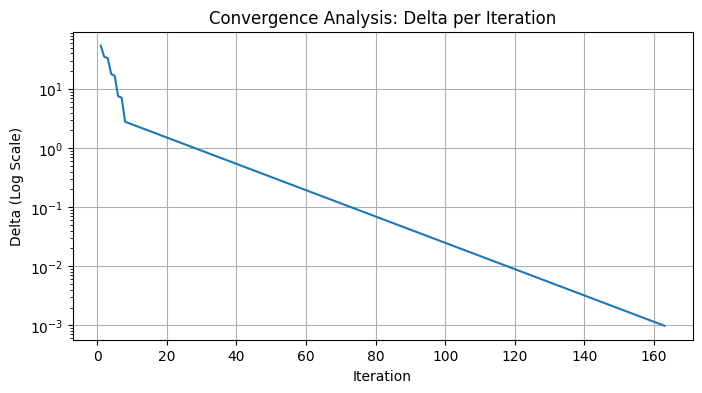

In [ ]:
# Add this cell right after your convergence log display
plt.figure(figsize=(8, 4))
plt.plot(convergence_log['iteration'], convergence_log['delta'])
plt.yscale('log') # Log scale is best for showing error decay
plt.title('Convergence Analysis: Delta per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Delta (Log Scale)')
plt.grid(True)
plt.show()

### Algorithm Performance & Convergence

The code above prints the number of reachable states, the number of Value Iteration sweeps, the runtime, and the final Bellman error.

Additionally, the plotted graph visualises this convergence by tracking the maximum Bellman error (`delta`) across each iteration. Using a logarithmic scale clearly demonstrates the exponential decay of the error as the algorithm rapidly approaches the optimal value function.

## 3. Policy Visualization and Rescue Trajectory

The following cells visualize:
- the preferred action at each cell for the initial rescue mask and full battery,
- a simulated rescue trajectory following the optimal policy,
- how the policy uses charging stations and avoids danger zones when beneficial.

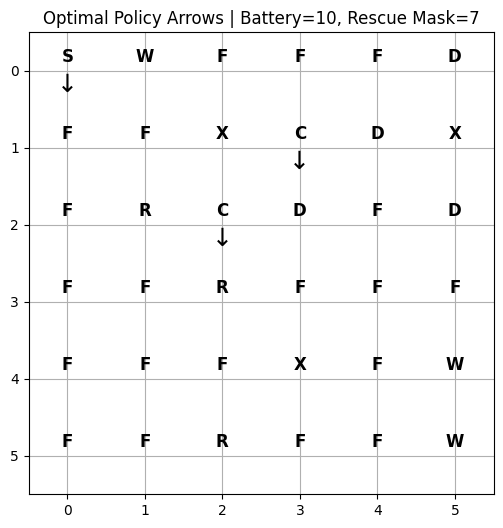

In [ ]:
#@title Optimal Policy Arrow Map

def plot_policy_grid(environment: DroneRescueEnv, policy, battery_level=None, rescue_mask=None):
    """This function draws the map and places an arrow in every cell showing the exact direction the drone should
    move according to your optimal policy. Because the policy changes depending on battery and targets, it visualises
     a single "slice" of time (defaulting to full battery and all targets pending).
    Args:
        environment: Drone rescue environment.
        policy: Mapping from states to optimal actions.
        battery_level: Fixed battery slice to visualize.
        rescue_mask: Fixed rescue-target status slice to visualize.
    """
    # If you don't specify a battery level, it defaults to checking what the drone would do with a full battery (10).
    if battery_level is None:
        battery_level = environment.config.max_battery
    # Defaults the mask to 7 (which is 111 in binary), meaning all 3 targets still need rescuing.
    if rescue_mask is None:
        rescue_mask = (1 << len(environment.rescue_targets)) - 1
    # Creates a 6x6 inch blank canvas for plotting.
    n = environment.config.grid_size
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(f'Optimal Policy Arrows | Battery={battery_level}, Rescue Mask={rescue_mask}')
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.grid(True)
    # Put cell symbols and policy arrows in each reachable non-blocked location.
    for r in range(n):
        for c in range(n):
            # Looks up what type of cell this is (e.g., 'F' for Free, 'D' for Danger).
            symbol = environment.grid[r, c]
            ax.text(c, r - 0.18, symbol, ha='center', va='center', fontsize=12, fontweight='bold')
            # Checks to ensure this isn't a blocked 'X' cell, since the drone can't be on those.
            if (r, c) not in environment.blocked_cells:
                # Builds the specific 4-part state tuple for the current cell.
                state = (r, c, battery_level, rescue_mask)
                # Checks if your DP algorithm actually calculated a best move for this state.
                if state in policy:
                    # Looks up the correct arrow symbol (↑, ↓, ←, →) for the optimal action and prints it
                    ax.text(c, r + 0.18, environment.ARROWS.get(policy[state], '?'), ha='center', va='center', fontsize=18)
    plt.show()

# Visualize the fixed-slice optimal policy and one sampled policy rollout.
plot_policy_grid(env, optimal_policy)

In [ ]:
#@title Policy Trajectory Simulation

def simulate_policy(environment: DroneRescueEnv, policy, max_steps=None, seed=None):
    """Simulate one episode by following the optimal policy.
    Args:
        environment: Drone rescue environment.
        policy: Optimal policy dictionary.
        max_steps: Optional safety cap; defaults to assignment step limit.
        seed: Optional RNG seed for reproducible wind outcomes.
    Returns:
        A DataFrame containing the full step-by-step trajectory.
    """
    # Resets the random number generator using the seed
    if seed is not None:
        environment.rng = np.random.default_rng(seed)
    # Sets the maximum number of steps allowed
    if max_steps is None:
        max_steps = environment.config.step_limit
    # Returns the drone to its starting position, resets battery levels, and clears the rescue target status.
    state = environment.reset()
    # Initializes an empty list to capture the data for each step of the simulation.
    trajectory = []
    # Follow the DP policy until termination or the assignment step limit.
    for step in range(max_steps):
        # Queries the policy dictionary for the optimal move based on the drone's current
        # state, defaulting to 'HOVER' if no action is defined.
        action = policy.get(state, 'HOVER')
        # Breaks the loop immediately if the current state is flagged as 'TERMINAL'.
        if action == 'TERMINAL':
            break
        # Executes the action in the environment and captures the outcome, including the new
        # state, reward, termination flag, and metadata.
        next_state, reward, done, info = environment.step(action)
        # Appends a dictionary containing all relevant step data
        trajectory.append({
            'step': step + 1,
            'state_before': state,
            'action': action,
            'state_after': next_state,
            'reward': reward,
            'battery_after': next_state[2],
            'pending_rescue_mask_after': next_state[3],
            'done': done
        })
        # Updates the current state to the next_state produced by the environment.
        state = next_state
        # Terminates the loop if the episode is marked as done (due to mission completion,
        # battery exhaustion, or reaching the step limit).
        if done:
            break
        # Converts the populated trajectory list into a Pandas DataFrame
    return pd.DataFrame(trajectory)

trajectory = simulate_policy(env, optimal_policy, seed=RANDOM_SEED + 101)
print('Trajectory length:', len(trajectory))
print('Trajectory total reward:', round(trajectory['reward'].sum(), 4) if len(trajectory) else 0)
display(trajectory)

Trajectory length: 75
Trajectory total reward: 320.0


,step,state_before,action,state_after,reward,battery_after,pending_rescue_mask_after,done
0,1,"(0, 0, 10, 7)",DOWN,"(1, 0, 9, 7)",-1.0,9,7,False
1,2,"(1, 0, 9, 7)",DOWN,"(2, 0, 8, 7)",-1.0,8,7,False
2,3,"(2, 0, 8, 7)",RIGHT,"(2, 1, 7, 5)",19.0,7,5,False
3,4,"(2, 1, 7, 5)",RIGHT,"(2, 2, 10, 5)",4.0,10,5,False
4,5,"(2, 2, 10, 5)",DOWN,"(3, 2, 9, 1)",19.0,9,1,False
...,...,...,...,...,...,...,...,...
70,71,"(2, 2, 10, 1)",UP,"(2, 2, 10, 1)",4.0,10,1,False
71,72,"(2, 2, 10, 1)",UP,"(2, 2, 10, 1)",4.0,10,1,False
72,73,"(2, 2, 10, 1)",UP,"(2, 2, 10, 1)",4.0,10,1,False
73,74,"(2, 2, 10, 1)",UP,"(2, 2, 10, 1)",4.0,10,1,False


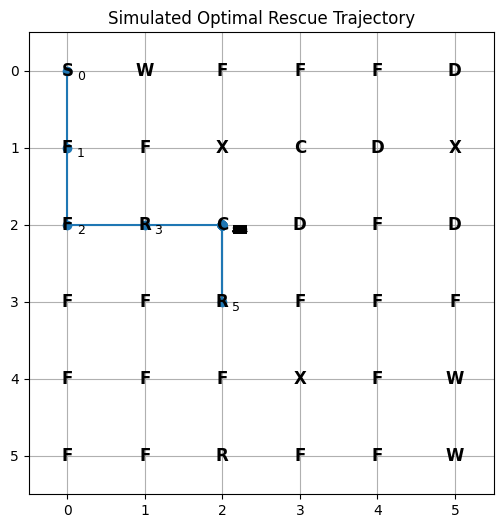

In [ ]:
#@title Rescue Path Trajectory Overlay

def plot_trajectory(environment: DroneRescueEnv, trajectory_df: pd.DataFrame):
    """Overlay the simulated trajectory path on the grid world."""
    # Retrieves the grid size (6) and creates a 6x6-inch plotting area.
    n = environment.config.grid_size
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title('Simulated Optimal Rescue Trajectory')
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.grid(True)
    # Iterates through every cell in the grid and places the environment symbols (S, R, C, D, X, W, F) as text labels.
    for r in range(n):
        for c in range(n):
            ax.text(c, r, environment.grid[r, c], ha='center', va='center', fontsize=12, fontweight='bold')
    # Starts a list with the origin (0,0), then iterates through the trajectory DataFrame to grab the (row, col)
    # coordinate after every single step taken by the drone.
    positions = [environment.start_pos]
    for _, row in trajectory_df.iterrows():
        positions.append((row['state_after'][0], row['state_after'][1]))
    # Splits the coordinate list into separate X and Y lists. draws a line connecting all those points
    y_values = [pos[0] for pos in positions]
    x_values = [pos[1] for pos in positions]
    ax.plot(x_values, y_values, marker='o')
    # Annotate order of visits to make rescue sequence clear in the PDF.
    for index, (r, c) in enumerate(positions):
        ax.text(c + 0.12, r + 0.12, str(index), fontsize=9)
    plt.show()

plot_trajectory(env, trajectory)

### Policy visualization observations
The visualizations above demonstrate the drone's optimal behaviour across four key areas:
*   **Movement Directions:** The arrow grid displays the optimal policy $\pi^*(s)$ for a full-battery state, clearly showing how the policy routes the drone toward high-reward rescue targets.
*   **Rescue Sequence:** The trajectory plot overlays the simulated path onto the grid, numbering the exact sequence in which the agent navigates to the pending targets.
*   **Avoidance of Dangerous Zones:** The simulated path actively routes around 'D' cells. As shown in the policy grid, danger cells are only entered if the value of a drastically shorter rescue path mathematically outweighs the -10 penalty.
*   **Preferred Charging Behaviour:** The trajectory demonstrates the drone utilizing charging stations (e.g., routing through the 'C' cell) to restore its battery, ensuring it has enough power to complete longer rescue sequences without terminating the episode.

## 4. State-Value Analysis

A meaningful state slice is selected by fixing:
- all rescue targets pending,
- battery level equal to the maximum battery,
- and varying only the drone position.

This creates a heatmap of \(V^*(s)\) over the grid. High-value cells are typically near rescue targets or safe routes. Low-value cells are typically near danger zones, blocked regions or positions that waste battery.

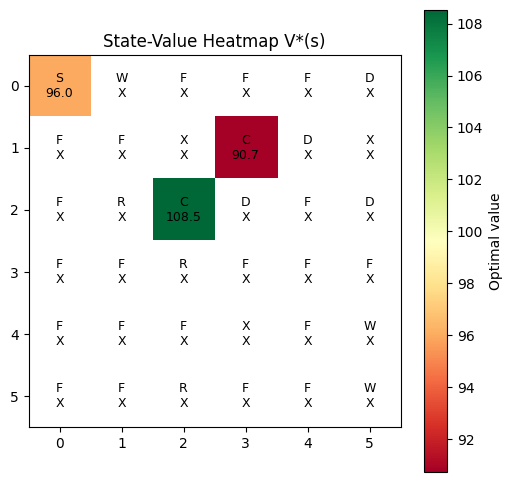

In [ ]:
# ================================================================
# State-value heatmap
# ================================================================
def build_value_heatmap(environment: DroneRescueEnv, V, battery_level=None, rescue_mask=None):
    """This function is a data-processing step. It transforms your V dictionary (which is a long list of state-value pairs
    like {(0,0,10,7): 95.9}) into a 2D matrix that Matplotlib can understand as an image."""
    # If no specific battery level or rescue mask is provided, it defaults to the maximum battery (10)
    # and a full set of pending targets (mask 7).
    if battery_level is None:
        battery_level = environment.config.max_battery
    if rescue_mask is None:
        rescue_mask = (1 << len(environment.rescue_targets)) - 1
    # Retrieves the grid size (6) from the environment configuration.
    n = environment.config.grid_size
    # Creates a 6x6 matrix filled with np.nan (Not a Number).
    heatmap = np.full((n, n), np.nan)
    # Fill each non-blocked position with its optimal value if the state is reachable.
    for r in range(n):
        for c in range(n):
            # Checks if the current cell coordinate is in blocked_cells, it continues
            if (r, c) in environment.blocked_cells:
                continue
            # Reconstructs the 4-part state tuple (r, c, battery_level, rescue_mask) for the current grid location.
            state = (r, c, battery_level, rescue_mask)
            # Checks if this specific state exists in the value function dictionary (V)
            if state in V:
                heatmap[r, c] = V[state]
    return heatmap

def plot_value_heatmap(environment: DroneRescueEnv, V, battery_level=None, rescue_mask=None):
    """Plot the fixed-slice optimal value function as a heatmap."""
    # Calls the build_value_heatmap function to transform the abstract V dictionary into a 6x6 numerical matrix.
    heatmap = build_value_heatmap(environment, V, battery_level, rescue_mask)
    # Retrieves the grid size (6) to set up the plot axes.
    n = environment.config.grid_size
    # Creates a 6x6-inch plotting area.
    fig, ax = plt.subplots(figsize=(6, 6))
    min_val = np.nanmin(heatmap)
    max_val = np.nanmax(heatmap)
    # 'RdYlGn' maps Red (Low) -> Yellow (Mid) -> Green (High)
    image = ax.imshow(heatmap, cmap='RdYlGn', vmin=min_val, vmax=max_val)
    ax.set_title('State-Value Heatmap V*(s)')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    # Annotate each cell with symbol and rounded value to improve readability.
    for r in range(n):
        for c in range(n):
            # Looks up the environment symbol (e.g., 'R', 'C', 'D') for the current cell.
            symbol = environment.grid[r, c]
            # Checks if the cell is NaN (unreachable/blocked). If not, it formats the value to one decimal place (:.1f).
            value_text = 'X' if np.isnan(heatmap[r, c]) else f'{heatmap[r, c]:.1f}'
            ax.text(c, r, f'{symbol}\n{value_text}', ha='center', va='center', fontsize=9)
    plt.colorbar(image, ax=ax, label='Optimal value')
    plt.show()

plot_value_heatmap(env, V_star)

### State-value interpretation

* The heatmap helps explain why the optimal policy selects certain paths.

* Cells with higher values are those from which the drone can still rescue civilians efficiently while preserving battery.

* Cells near danger zones or blocked areas may have lower values because they increase expected penalty, route length or risk.

* Charging stations can raise nearby values because they restore battery and support longer rescue plans.

## 5. DP Scalability Discussion

### 5.1 Curse of Dimensionality

Dynamic Programming requires explicit enumeration of states and repeated Bellman backups over those states. In this problem, the approximate number of states grows like:$$|S| \approx \text{rows} \times \text{cols} \times \text{battery_levels} \times 2^{\text{rescue_targets}}$$

**Grid Expansion:** Moving from a $6 \times 6$ to a $10 \times 10$ grid nearly triples the spatial state factor.

**Target Growth:** Adding rescue targets is the most critical constraint; because the state space uses a bitmask ($2^n$), each new target doubles the number of states, leading to exponential growth.

**Dynamic Complexity:** Adding environmental variables like weather conditions adds further multiplicative factors, making the state table quickly unmanageable.

### 5.2 Is DP sufficient?

While DP is optimal for this small-scale, known environment, it fails in real-world autonomous systems for several reasons:

* Memory & Compute: As state complexity grows, the memory required to store the Value function table exceeds system RAM, and the time required for iterative convergence becomes prohibitive.
* Model-Dependency: DP requires a perfect transition model $P(s'|s, a)$. Real-world environments are often partially observable or stochastic in ways that are impossible to model with the precision required for exact DP.

**How Deep RL Helps**

Deep Reinforcement Learning (DRL) addresses these limitations by using function approximation (Neural Networks) rather than tabular storage:

* Generalization: A neural network learns to generalize values across similar states. If the drone learns that a specific pattern of danger zones is high-risk in one area, it can infer this risk elsewhere without having visited every single exact state.

* High-Dimensional Inputs: DRL allows agents to operate directly on raw sensor data or continuous state spaces, enabling the robust, real-time decision-making required for modern, large-scale autonomous drone operations.

**Relation to real-world autonomous drone systems**

* Similarities: The MDP perfectly captures real-world drone trade-offs like finite battery management, stochastic wind disturbances, and hazard avoidance.  
* Limitations: Real drones navigate continuous 3D environments using imperfect, live sensor data rather than pre-mapped, fully observable grids.  
* Why Deep RL: Real-world complexity triggers the Curse of Dimensionality. This makes exact DP mathematically impossible, requiring Deep RL to process infinite state spaces in real-time.